In [328]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [298]:
df = pd.read_csv("netflix_titles.csv")


In [299]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [300]:
df.tail(5
        )

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [301]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [302]:
df.shape

(8807, 12)

In [303]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [305]:
df.duplicated().sum(
    
)

np.int64(0)

In [306]:
#Missing values handling
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [307]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)


In [308]:
df['date_added'] = df['date_added'].str.strip()# remove extra spaces

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [309]:
df['date_added'].isna().sum()

np.int64(10)

In [310]:
df = df.dropna(subset=['date_added'])

In [311]:
df['date_added'].isna().sum()

np.int64(0)

In [312]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.replace('\d+', '', regex=True).str.strip()

In [336]:
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0])

In [337]:
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

In [338]:
text_cols = ['director','cast','country','rating','type']

for col in text_cols:
    df[col] = df[col].str.strip()

In [340]:
df['rating'].value_counts()
df['rating'] = df['rating'].str.replace(' ', '-')

In [341]:
df.drop('show_id', axis=1, inplace=True)

In [344]:
df['release_year'].describe()


count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [345]:

df['duration_num'].describe()

count    8794.000000
mean       69.920173
std        50.797005
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: duration_num, dtype: float64

In [347]:
df['type'].unique()


array(['Movie', 'TV Show'], dtype=object)

In [348]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74-min', '84-min', '66-min', 'NR',
       'TV-Y7-FV', 'UR'], dtype=object)

In [349]:
df['primary_country'].unique()[:20]

array(['United States', 'South Africa', 'Unknown', 'India',
       'United Kingdom', 'Germany', 'Mexico', 'Turkey', 'Australia',
       'Finland', 'China', 'Nigeria', 'Japan', 'Spain', 'France',
       'Belgium', 'South Korea', 'Argentina', 'Russia', 'Canada'],
      dtype=object)

In [350]:
df.isnull().sum()

type                        0
title                       0
director                    0
cast                        0
country                     0
date_added                  0
release_year                0
rating                      0
duration                    3
listed_in                   0
description                 0
duration_num                3
duration_type               3
year_added                  0
month_added                 0
content_age                 0
genre_count                 0
content_age_group           0
seasons                  7924
movie_length_category       3
country_count               0
cast_count                  0
primary_genre               0
is_netflix_original         0
primary_country             0
dtype: int64

In [352]:
df['duration'].fillna('Unknown', inplace=True)
df['duration_num'].fillna(df['duration_num'].median(), inplace=True)
df['duration_type'].fillna('Unknown', inplace=True)

In [353]:
df['movie_length_category'] = pd.cut(
    df['duration_num'],
    bins=[0,60,90,120,180,400],
    labels=['Short','Medium','Long','Very Long','Epic']
)

In [354]:
df.isnull().sum()

type                        0
title                       0
director                    0
cast                        0
country                     0
date_added                  0
release_year                0
rating                      0
duration                    0
listed_in                   0
description                 0
duration_num                0
duration_type               0
year_added                  0
month_added                 0
content_age                 0
genre_count                 0
content_age_group           0
seasons                  7924
movie_length_category       0
country_count               0
cast_count                  0
primary_genre               0
is_netflix_original         0
primary_country             0
dtype: int64

In [342]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   type                   8797 non-null   object        
 1   title                  8797 non-null   object        
 2   director               8797 non-null   object        
 3   cast                   8797 non-null   object        
 4   country                8797 non-null   object        
 5   date_added             8797 non-null   datetime64[ns]
 6   release_year           8797 non-null   int64         
 7   rating                 8797 non-null   object        
 8   duration               8794 non-null   object        
 9   listed_in              8797 non-null   object        
 10  description            8797 non-null   object        
 11  duration_num           8794 non-null   float64       
 12  duration_type          8794 non-null   object        
 13  year_add

# Feature Engineering

In [313]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [314]:
df['content_age'] = 2024 - df['release_year']

In [315]:
df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))

In [326]:
df['content_age_group'] = pd.cut(
    df['content_age'],
    bins=[0,5,10,20,50,100],
    labels=['0-5 yrs','6-10 yrs','11-20 yrs','21-50 yrs','50+ yrs']
)

In [329]:
df['seasons'] = np.where(
    df['duration_type']=='Seasons',
    df['duration_num'],
    np.nan
)

In [330]:
df['movie_length_category'] = pd.cut(
    df['duration_num'],
    bins=[0,60,90,120,180,400],
    labels=['Short','Medium','Long','Very Long','Epic']
)

In [333]:
df['cast_count'] = df['cast'].apply(lambda x: len(x.split(',')))

In [ ]:
df['date_added'].isna().sum()

np.int64(10)

In [332]:
df['country_count'] = df['country'].apply(lambda x: len(x.split(',')))

In [331]:
df['date_added'].isna().sum()

np.int64(0)

In [335]:
df['is_netflix_original'] = df['title'].str.contains('Netflix', case=False)

In [334]:
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

# EDA

In [316]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

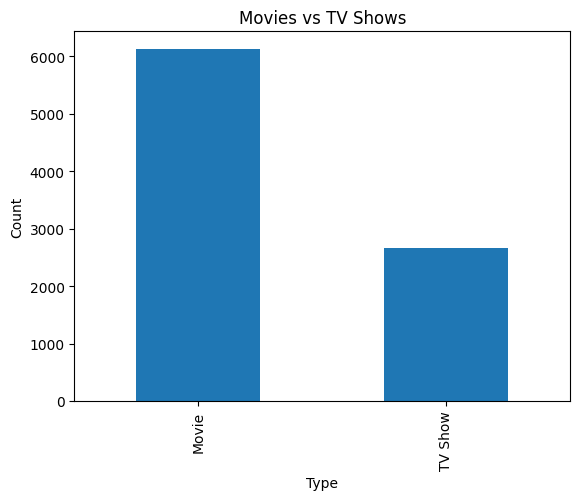

In [ ]:
df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows")   # correct function
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

Insights: Netflix pe moives zyada hai ya shows ?


In [318]:
df['country'].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

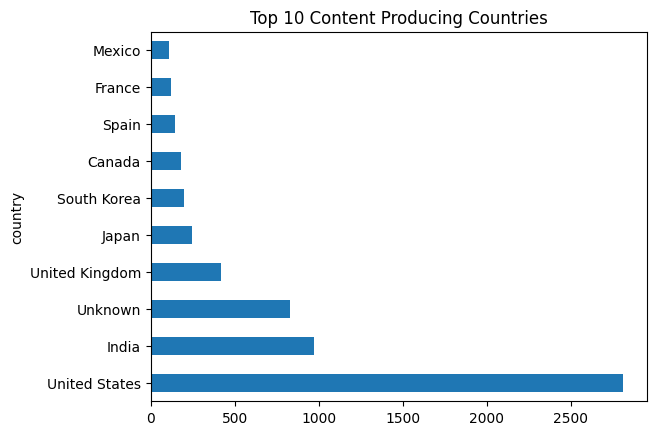

In [319]:
df['country'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Content Producing Countries")
plt.show()

Insights: USA and India

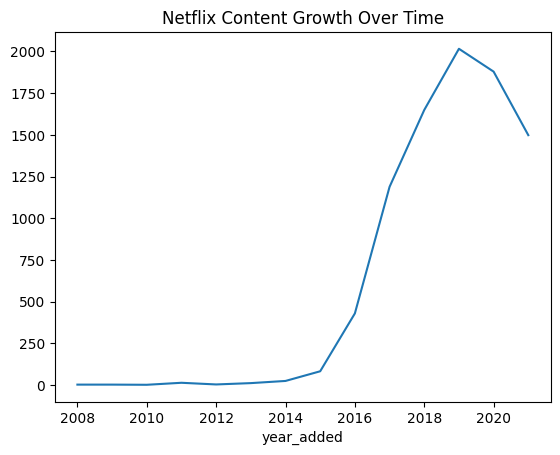

In [320]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Netflix Content Growth Over Time")
plt.show()

Insights: After 2016 explosion

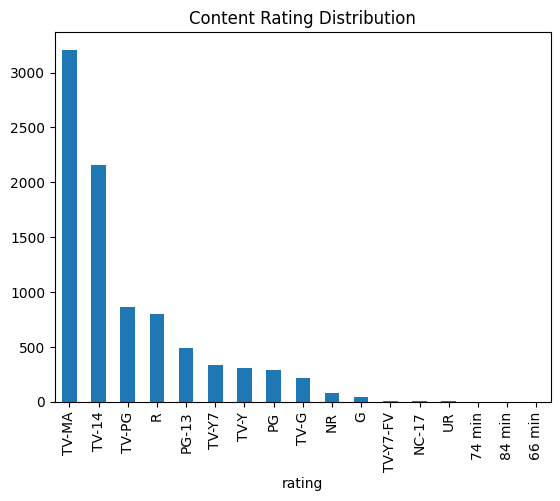

In [321]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Content Rating Distribution")
plt.show()

Insights: TV-MA AND TV14 

# Outlier Detection

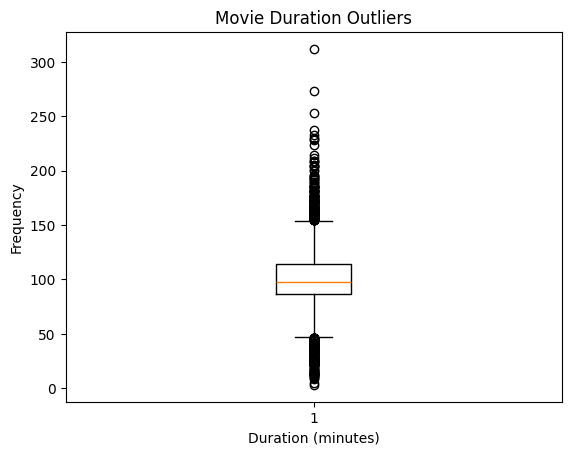

In [322]:
movies = df[df['type']=='Movie']

plt.boxplot(movies['duration_num'].dropna())
plt.title("Movie Duration Outliers")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

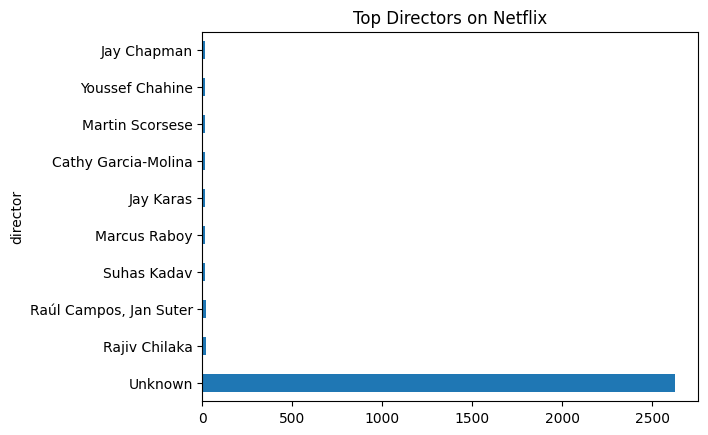

In [323]:
df['director'].value_counts().head(10).plot(kind='barh')
plt.title("Top Directors on Netflix")
plt.show()

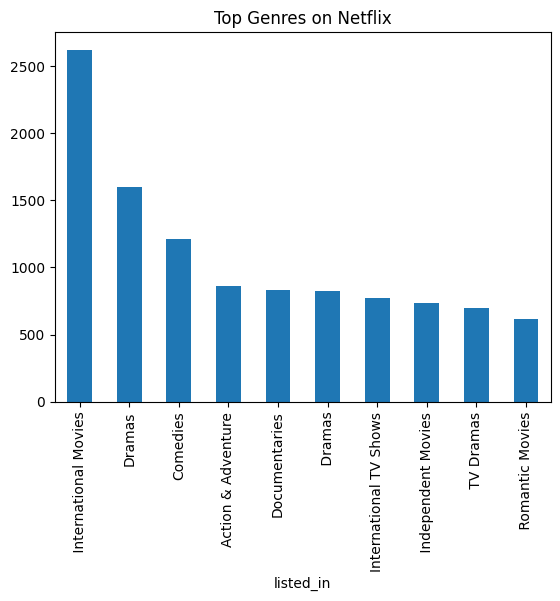

In [324]:
from collections import Counter

genres = df['listed_in'].str.split(',').explode()
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

Insights: International movies and Drama

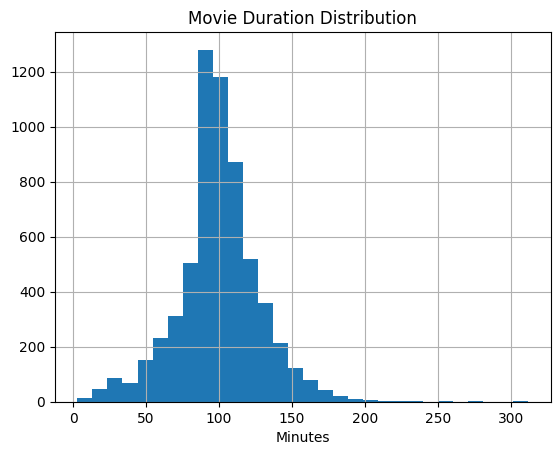

In [325]:
movies['duration_num'].hist(bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.show()

Insight:

Most movies 80–120 mins.

In [355]:
df.to_csv("netflix_cleaned.csv", index=False)

In [356]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'duration_num', 'duration_type', 'year_added', 'month_added',
       'content_age', 'genre_count', 'content_age_group', 'seasons',
       'movie_length_category', 'country_count', 'cast_count', 'primary_genre',
       'is_netflix_original', 'primary_country'],
      dtype='object')